<a href="https://colab.research.google.com/github/uzairbaig8110-cloud/CSL701-02-Machine-Learning-Lab/blob/main/experiments/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Uzair I Baig

Batch : CS-1


Roll Number :CS-02



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('/content/data[1].csv')

# Display first five rows
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Shape: (569, 33)

Column Names:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0

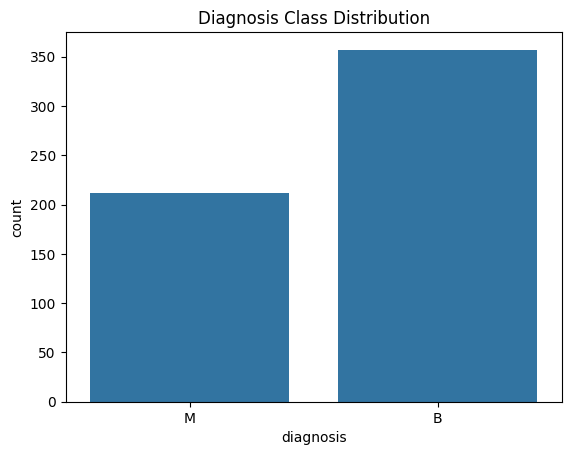

In [ ]:
# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Target class distribution
print("\nDiagnosis Distribution:")
print(df['diagnosis'].value_counts())

# Visualize class distribution
sns.countplot(data=df, x='diagnosis')
plt.title("Diagnosis Class Distribution")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Convert diagnosis into numerical values
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature Matrix Shape: (569, 30)
Target Vector Shape: (569,)

Features:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_

# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Dataset Shape:", X_scaled.shape)

# Display first five rows
print("\nFirst Five Rows of Scaled Data:")
print(X_scaled[:5])

# Check mean and standard deviation
print("\nFeature Means (first 5):")
print(X_scaled.mean(axis=0)[:5])

print("\nFeature Standard Deviations (first 5):")
print(X_scaled.std(axis=0)[:5])

Scaled Dataset Shape: (569, 30)

First Five Rows of Scaled Data:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Apply PCA to reduce 30 features to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis'] = y.values

print("PCA Dataset Shape:", X_pca.shape)
print("\nFirst Five Rows of PCA Data:")
print(pca_df.head())

PCA Dataset Shape: (569, 2)

First Five Rows of PCA Data:
        PC1        PC2  diagnosis
0  9.192837   1.948583          1
1  2.387802  -3.768172          1
2  5.733896  -1.075174          1
3  7.122953  10.275589          1
4  3.935302  -1.948072          1


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


Variance Explained by PC1: 0.44272025607526366
Variance Explained by PC2: 0.18971182044033078
Total Variance Retained: 0.6324320765155944

Variance Explained by PC1 (%): 44.272025607526366
Variance Explained by PC2 (%): 18.97118204403308
Total Variance Retained (%): 63.243207651559445


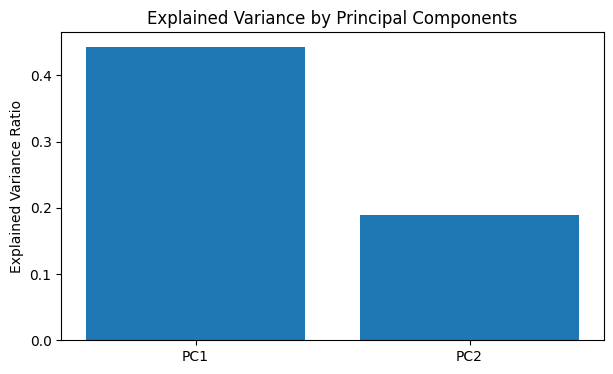

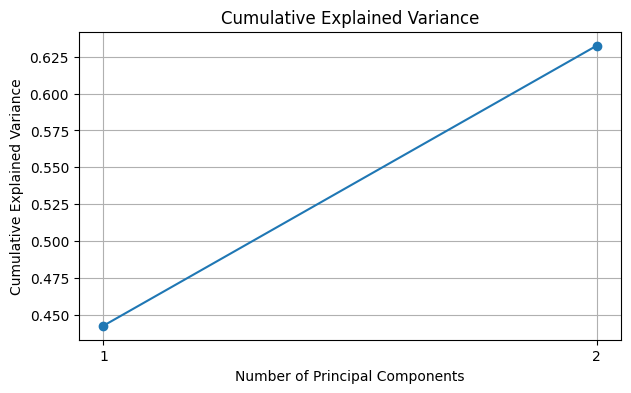

In [ ]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Variance Explained by PC1:", explained_variance[0])
print("Variance Explained by PC2:", explained_variance[1])
print("Total Variance Retained:", explained_variance.sum())

print("\nVariance Explained by PC1 (%):", explained_variance[0] * 100)
print("Variance Explained by PC2 (%):", explained_variance[1] * 100)
print("Total Variance Retained (%):", explained_variance.sum() * 100)

# Plot explained variance
plt.figure(figsize=(7, 4))
plt.bar(['PC1', 'PC2'], explained_variance)
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.show()

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 3), cumulative_variance, marker='o')
plt.xticks([1, 2])
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

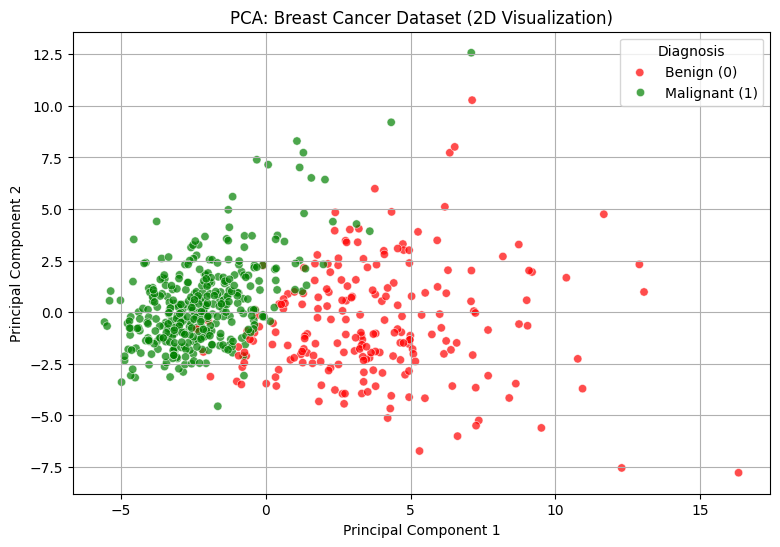

In [ ]:
# Scatter plot of PCA-transformed data
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='diagnosis',
    palette={0: 'green', 1: 'red'},
    alpha=0.7
)

plt.title('PCA: Breast Cancer Dataset (2D Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diagnosis', labels=['Benign (0)', 'Malignant (1)'])
plt.grid(True)
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
# Split original scaled dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Logistic Regression
model_raw = LogisticRegression(max_iter=10000)
model_raw.fit(X_train, y_train)

# Predict
y_pred_raw = model_raw.predict(X_test)

# Evaluate
print("Original 30 Features Model")
print("Accuracy:", accuracy_score(y_test, y_pred_raw))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_raw))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_raw, target_names=['Benign', 'Malignant']))

Original 30 Features Model
Accuracy: 0.9649122807017544

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# Split PCA dataset
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Logistic Regression
model_pca = LogisticRegression(max_iter=10000)
model_pca.fit(X_train_pca, y_train_pca)

# Predict
y_pred_pca = model_pca.predict(X_test_pca)

# Evaluate
print("PCA 2 Components Model")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_pca))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nClassification Report:")
print(classification_report(y_test_pca, y_pred_pca, target_names=['Benign', 'Malignant']))

PCA 2 Components Model
Accuracy: 0.9385964912280702

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



Model Performance Comparison:
                                    Model  Accuracy
0       Logistic Regression (30 Features)  0.964912
1  Logistic Regression (2 PCA Components)  0.938596


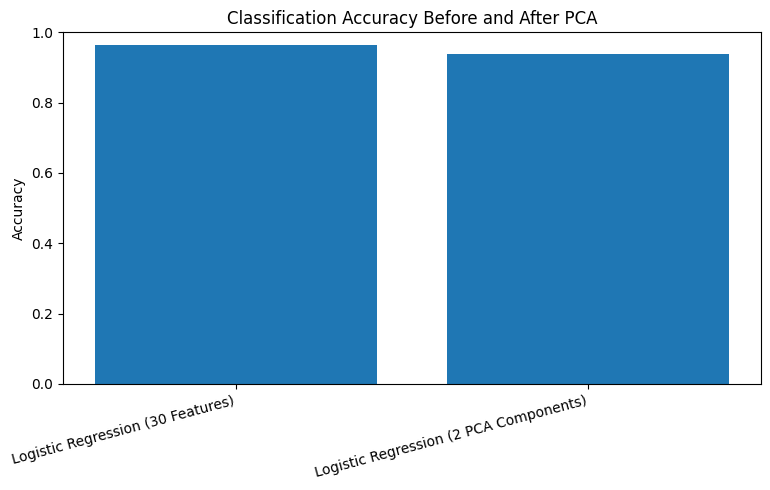

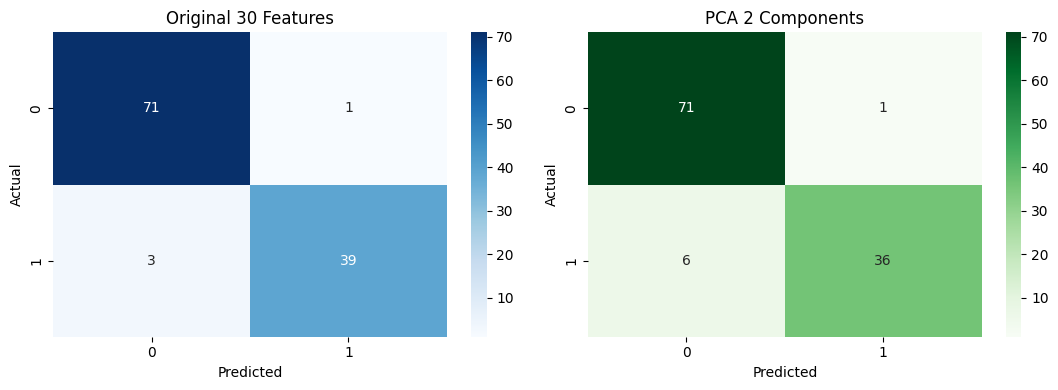

In [ ]:
# Calculate accuracy scores
accuracy_raw = accuracy_score(y_test, y_pred_raw)
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (30 Features)',
              'Logistic Regression (2 PCA Components)'],
    'Accuracy': [accuracy_raw, accuracy_pca]
})

print("Model Performance Comparison:")
print(comparison)

# Plot accuracy comparison
plt.figure(figsize=(8, 5))

plt.bar(comparison['Model'], comparison['Accuracy'])
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Before and After PCA')
plt.ylim(0, 1.0)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_raw),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Original 30 Features')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(
    confusion_matrix(y_test_pca, y_pred_pca),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title('PCA 2 Components')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.